## A Comprehensive Guide to Simulating
Microwave Toroidal Pulse Generation
with Python MEEP

In [1]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid


def make_horn_antenna_geometry(
    r_in_start, r_in_end, r_out_start, r_out_end, h,
    taper_profile='linear', n_slices=100, material=mp.metal
):
    """
    Generates a list of MEEP geometry objects for a horn-like antenna.

    For a 'linear' profile, this function defines the horn wall's cross-section
    as a single mp.Prism, which is the most efficient and accurate method.
    For curved profiles ('quadratic', 'exponential'), it approximates the shape
    by stacking thin annular slices made of mp.Block objects.

    Args:
        r_in_start (float): Inner radius at the base (z=0).
        r_in_end (float): Inner radius at the horn opening (z=h).
        r_out_start (float): Outer radius at the base (z=0).
        r_out_end (float): Outer radius at the horn opening (z=h).
        h (float): Height of the horn along the z-axis.
        taper_profile (str): The profile of the flare. Can be 'linear', 'quadratic', or 'exponential'.
        n_slices (int): Number of slices to approximate curved geometries. Only used for non-linear profiles.
        material (meep.Material): The material for the antenna walls.

    Returns:
        list: A list of meep.GeometricObject instances.
    """
    if taper_profile == 'linear':
        # For a straight-sided horn, we can define the entire cross-section
        # as a single Prism. For 2D/cylindrical simulations, the height is set
        # to infinity and MEEP uses the 2D vertices as the shape.
        vertices = [
            mp.Vector3(x=r_in_start, z=0),
            mp.Vector3(x=r_out_start, z=0),
            mp.Vector3(x=r_out_end, z=h),
            mp.Vector3(x=r_in_end, z=h)
        ]
        # The correct object is Prism, not Polygon.
        geometry = [mp.Prism(vertices=vertices, height=mp.inf, material=material)]
        return geometry

    # For curved profiles, we fall back to the slicing method
    geometry = []
    z_coords = np.linspace(0, h, n_slices, endpoint=False)
    slice_height = h / n_slices

    for i, z_start in enumerate(z_coords):
        z_mid = z_start + 0.5 * slice_height
        # Normalized position along the horn length (0 to 1)
        s = z_mid / h

        # Calculate radii based on the selected taper profile
        if taper_profile == 'quadratic':
            slice_r_outer = r_out_start + (r_out_end - r_out_start) * s**2
            slice_r_inner = r_in_start + (r_in_end - r_in_start) * s**2
        elif taper_profile == 'exponential':
            # Ensure start radius is not zero for log scale
            r_out_start_safe = max(r_out_start, 1e-9)
            r_in_start_safe = max(r_in_start, 1e-9)
            slice_r_outer = r_out_start_safe * np.exp(np.log(r_out_end / r_out_start_safe) * s)
            slice_r_inner = r_in_start_safe * np.exp(np.log(r_in_end / r_in_start_safe) * s)
        else:
            # This case should not be hit if 'linear' is handled above, but it's good practice.
            raise ValueError("Invalid taper_profile. Choose from 'linear', 'quadratic', 'exponential'.")

        # Outer Wall using a block, which represents an annulus in 3D
        geometry.append(mp.Block(
            material=material,
            center=mp.Vector3(x=(slice_r_outer + slice_r_inner) / 2, z=z_mid),
            size=mp.Vector3(x=slice_r_outer - slice_r_inner, z=slice_height)
        ))

    return geometry

def visualize_geometry_2d(geometry, h, r_max):
    """
    Visualizes the 2D cross-section of the antenna geometry in the (r,z) plane.
    This is how MEEP's cylindrical solver interprets the geometry.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    for obj in geometry:
        if isinstance(obj, mp.Prism):
            # For a Prism, extract vertices and draw a polygon
            verts = [(v.x, v.z) for v in obj.vertices]
            poly = plt.Polygon(verts, facecolor='royalblue', edgecolor='darkblue')
            ax.add_patch(poly)
        elif isinstance(obj, mp.Block):
            # For a Block, calculate corners and draw a rectangle
            center = obj.center
            size = obj.size
            r_center, z_center = center.x, center.z
            r_size, z_size = size.x, size.z
            r_min = r_center - r_size / 2
            z_min = z_center - z_size / 2
            rect = plt.Rectangle((r_min, z_min), r_size, z_size, facecolor='royalblue', edgecolor='darkblue')
            ax.add_patch(rect)

    ax.set_title("2D Cross-Section of Horn Antenna (r-z plane)")
    ax.set_xlabel("Radius (r)")
    ax.set_ylabel("Height (z)")
    ax.set_xlim(0, r_max * 1.1)
    ax.set_ylim(0, h * 1.1)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()




Generating horn antenna with 'linear' taper profile...
Generated 1 geometric objects.
Displaying 2D cross-section (as seen by MEEP)...


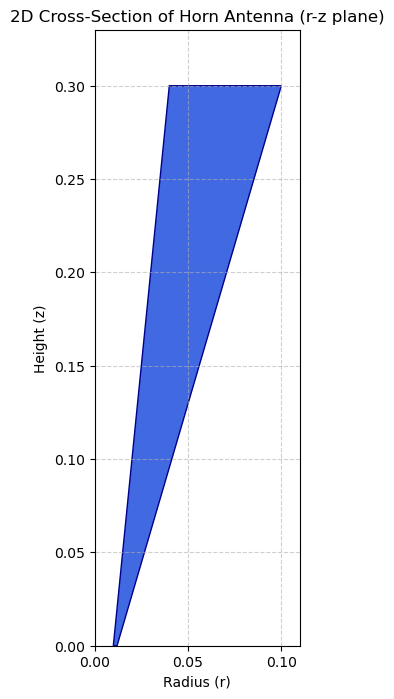

In [2]:

    
# Coaxial feed section at the base
feed_inner_radius = 0.01
feed_outer_radius = 0.012
    
# Horn opening at the top
horn_inner_radius = 0.04
horn_outer_radius = 0.10
    
# Height of the horn
horn_height = 0.30

# Choose the flare profile: 'linear', 'quadratic', 'exponential'
profile = 'linear'

print(f"Generating horn antenna with '{profile}' taper profile...")

# 1. Generate the MEEP geometry list
# The material is mp.metal, which corresponds to a Perfect Electric Conductor (PEC).
horn_geometry = make_horn_antenna_geometry(
        r_in_start=feed_inner_radius,
        r_in_end=horn_inner_radius,
        r_out_start=feed_outer_radius,
        r_out_end=horn_outer_radius,
        h=horn_height,
        taper_profile=profile,
        n_slices=50  # n_slices is ignored for the 'linear' profile now
)

print(f"Generated {len(horn_geometry)} geometric objects.")

    # 2. Visualize the 2D cross-section
print("Displaying 2D cross-section (as seen by MEEP)...")
visualize_geometry_2d(horn_geometry, horn_height, horn_outer_radius)



### 2. SOURCE DEFINITION

In [3]:
def create_source_waveform(fcen):
    """
    Creates an interpolated, time-integrated Ricker wavelet function for the source.
    This function encapsulates the analytical pulse definition and its preparation.
    
    Args:
        fcen (float): The center frequency of the Ricker wavelet.

    Returns:
        function: A function of time `t` that MEEP can use as a custom source.
    """
    # Define the analytical pulse for the radial E-field (Er)
    def ricker_wavelet(t, fcen):
        t0 = 2.0 / fcen  # Time shift to center the pulse away from t=0
        arg = (np.pi * fcen * (t - t0))**2
        return (1.0 - 2.0 * arg) * np.exp(-arg)

    # Generate the time-integrated feed signal g_f(t) on a fine time grid
    dt_source = 1 / (25 * fcen)
    t_max_source = 8 / fcen
    time_steps = np.arange(0, t_max_source, dt_source)
    Er_at_feed = ricker_wavelet(time_steps, fcen)
    g_f = cumulative_trapezoid(Er_at_feed, time_steps, initial=0)

    # Create an interpolation function that MEEP can call at its own time steps
    def source_function(t):
        return np.interp(t, time_steps, g_f)
        
    return source_function

def define_sources(source_waveform_func, feed_inner_radius, feed_outer_radius, sz, dpml):
    """
    Creates and returns the MEEP source object list based on the waveform and geometry.

    Args:
        source_waveform_func (function): The function defining the source's time-domain signal.
        feed_inner_radius (float): Inner radius of the coaxial feed.
        feed_outer_radius (float): Outer radius of the coaxial feed.
        sz (float): Axial size of the computational cell.
        dpml (float): Thickness of the PML layers.

    Returns:
        list: A list containing the configured mp.Source object.
    """
    source_center_r = (feed_inner_radius + feed_outer_radius) / 2
    source_size_r = feed_outer_radius - feed_inner_radius
    source_center_z = -sz / 2 + dpml + 0.1

    sources = [
        mp.Source(
            src=mp.CustomSource(src_func=source_waveform_func),
            component=mp.Er,
            center=mp.Vector3(x=source_center_r, z=source_center_z),
            size=mp.Vector3(x=source_size_r, z=0)
        )
    ]
    return sources

###  3. SIMULATION SETUP & EXECUTION

In [4]:
# --- 3. SIMULATION SETUP & EXECUTION ---
def setup_simulation(cell_size, resolution, pml_layers, geometry, sources):
    """
    Initializes and returns the MEEP Simulation object.
    """
    return mp.Simulation(
        cell_size=cell_size,
        resolution=resolution,
        boundary_layers=pml_layers,
        geometry=geometry,
        sources=sources,
        dimensions=mp.CYLINDRICAL,
        m=0
    )

def plot_simulation_results(sim, sr, sz):
    """
    Fetches the E-field data from the completed simulation and generates a plot.
    """
    plot_vol = mp.Volume(center=mp.Vector3(x=sr/2, z=0), size=mp.Vector3(x=sr, z=sz))
    # Corrected line: Use sim.get_array with a specified component and volume.
    er_data = sim.get_array(component=mp.Er, vol=plot_vol)

    plt.figure(figsize=(10, 8))
    # Handle case where field data might be all zeros to avoid plotting errors
    max_val = np.max(abs(er_data))
    vmin, vmax = (-max_val, max_val) if max_val > 0 else (-1, 1)

    plt.imshow(np.transpose(er_data), interpolation='spline36', cmap='RdBu',
               extent=[-sz/2, sz/2, 0, sr], vmin=vmin, vmax=vmax)
    plt.title("Radial Electric Field (Er) at Simulation End")
    plt.xlabel("z (meters)")
    plt.ylabel("r (meters)")
    plt.colorbar(label="Er (arbitrary units)")
    plt.show()


### Main workflow

In [5]:
# --- 4. MAIN WORKFLOW ---

# Simulation Parameters
resolution = 25
dpml = 1.0
sr = 0.5
sz = 3.0
cell_size = mp.Vector3(sr + dpml, 0, sz + 2 * dpml)
pml_layers = [mp.PML(thickness=dpml)]


# Source Parameters
fcen = 6e9


print("Step 2: Defining custom source...")
source_waveform = create_source_waveform(fcen)
sources = define_sources(source_waveform, feed_inner_radius, feed_outer_radius, sz, dpml)


Step 2: Defining custom source...


In [6]:
print("Step 3: Setting up MEEP simulation...")
sim = mp.Simulation(
        cell_size=cell_size,
        resolution=resolution,
        boundary_layers=pml_layers,
        geometry=horn_geometry,
        sources=sources,
        dimensions=mp.CYLINDRICAL,
        m=0
    )

print("Step 4: Running simulation...")
sim.run(until=15)

print("Step 5: Visualizing results...")
plot_simulation_results(sim, sr, sz)
    
print("Simulation finished.")

: 